# Build a Neural Network from Scratch

## Digit Recogniser


In [71]:
# Import packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [72]:
# Import data
data = pd.read_csv('train.csv')

In [73]:
# Inspect top of data
data.head(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [74]:
# Convert to numpy array for manipulation
data = np.array((data))

In [75]:
# Get dimensions of data
m, n = data.shape

In [76]:
print(f' The data contains {m} rows and {n} columns')

 The data contains 42000 rows and 785 columns


In [77]:
# Shuffle data - this ensures that each subset will include a mix of all cases / patterns, in the even that the original dataset is ordered in any way
np.random.shuffle(data)

In [78]:
# Split data into dev and train sets
data_dev = data[0:1000].T # First 1000 rows, transposed
Y_dev = data_dev[0] # Select all columns, but only row 0 (labels)
X_dev = data_dev[1:n] # Select all columns, and rows 1 through n-1 (the features). Selects every row except the first (labels)
X_dev = X_dev / 255

data_train = data[1000:m].T # All of the rest of the data, transposed
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255
_, m_train = X_train.shape

In [79]:
Y_train

array([2, 4, 2, ..., 4, 5, 8], shape=(41000,))

In [80]:
X_train[:, 0].shape

(784,)

In [81]:
# Initialise parameters - create the network structure with random starting values
def init_params():
    W1 = np.random.rand(10, 784) - 0.5 # Matrix of weights connecting the input layer to the first hidden layer
    b1 = np.random.rand(10, 1) - 0.5 # A bias for ach of the 10 hidden neurons
    W2 = np.random.rand(10, 10) - 0.5 # Weights connecting the first hidden layer to the output layer
    b2 = np.random.rand(10, 1) - 0.5 # Bias for each of the 10 output neurons
    return W1, b1, W2, b2


In [82]:
# Define ReLU a non-linear activation function
# Keep positive values, zero out negative values - this allows the network to learn non-linear patterns
def ReLU(Z):
    return np.maximum(Z, 0)

In [83]:
# Define softmax - convert raw scores into probabilities
def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

In [84]:
# Define forward propagation - pass X through the network to compute predictions
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1 # Hidden layer: linear transformation
    A1 = ReLU(Z1) # Hidden layer: non-linear activation
    Z2 = W2.dot(A1) + b2 # Output layer: linear transformation
    A2 = softmax(Z2) # Output layer: convert to probabilities
    return Z1, A1, Z2, A2

In [85]:
# Define one hot - convert integer labels into one-hot encoded vectors
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1)) # Create a matrix of zeros
    one_hot_Y[np.arange(Y.size), Y] = 1 # For each example, set the appropriate class column to 1
    one_hot_Y = one_hot_Y.T # Transpose so classes are in rows, examples are in columns
    return one_hot_Y

In [86]:
# Define deriv_ReLU
def deriv_ReLU(Z):
    return Z > 0

In [87]:
# Define backpropagation - compute gradients for all weights and biases
def back_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

In [88]:
# Define update parameters using gradient descent
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [89]:
# Define get predictions - convert probability matrix to class predictions
def get_predictions(A2):
    return np.argmax(A2, 0)

In [90]:
# Define get accuracy - calculate classification accuracy
def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

In [91]:
# Define gradient descent - train the neural network using gradient descent
def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params() # Initialise parameters randomly
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X) # Forward propagation (make predictions)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W1, W2, X, Y) # Backpropagation (compute gradients)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha) # Update parameters
        if i % 10 == 0: # Print progress every 10 iterations
            print('Iteration: ', i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [92]:
# Run the model
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.10)

Iteration:  0
[1 7 7 ... 1 7 3] [2 4 2 ... 4 5 8]
0.119
Iteration:  10
[1 4 2 ... 1 7 3] [2 4 2 ... 4 5 8]
0.24785365853658536
Iteration:  20
[1 4 2 ... 1 6 3] [2 4 2 ... 4 5 8]
0.32746341463414635
Iteration:  30
[1 4 2 ... 1 0 3] [2 4 2 ... 4 5 8]
0.39202439024390245
Iteration:  40
[1 4 2 ... 4 0 3] [2 4 2 ... 4 5 8]
0.44751219512195123
Iteration:  50
[1 4 2 ... 4 0 3] [2 4 2 ... 4 5 8]
0.4901219512195122
Iteration:  60
[2 4 2 ... 4 0 3] [2 4 2 ... 4 5 8]
0.5284146341463415
Iteration:  70
[2 4 2 ... 4 0 3] [2 4 2 ... 4 5 8]
0.5619756097560976
Iteration:  80
[2 4 2 ... 4 0 3] [2 4 2 ... 4 5 8]
0.5888536585365853
Iteration:  90
[2 4 2 ... 4 0 3] [2 4 2 ... 4 5 8]
0.6125365853658536
Iteration:  100
[2 4 2 ... 4 0 3] [2 4 2 ... 4 5 8]
0.6319512195121951
Iteration:  110
[2 4 2 ... 4 0 3] [2 4 2 ... 4 5 8]
0.6495121951219512
Iteration:  120
[2 4 2 ... 4 0 3] [2 4 2 ... 4 5 8]
0.6651707317073171
Iteration:  130
[2 4 2 ... 4 0 3] [2 4 2 ... 4 5 8]
0.6795121951219513
Iteration:  140
[2 4 2 ...

In [96]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

In [97]:
def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [2]
Label:  2


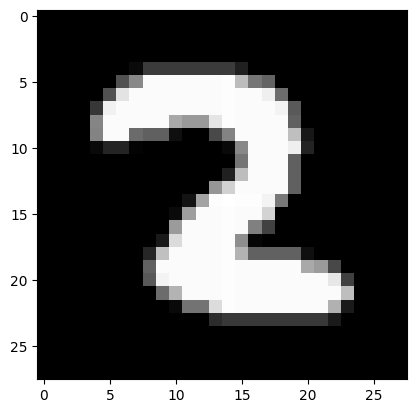

Prediction:  [4]
Label:  4


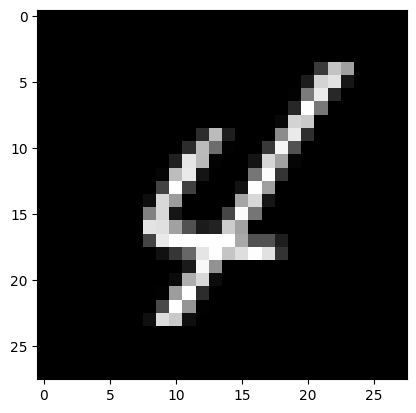

Prediction:  [2]
Label:  2


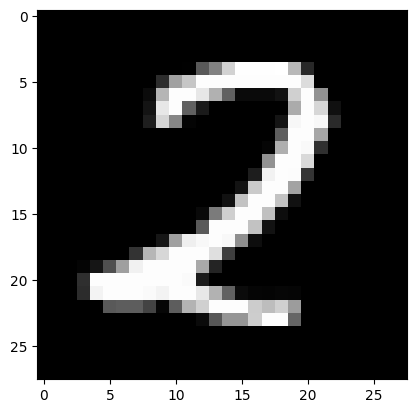

Prediction:  [2]
Label:  2


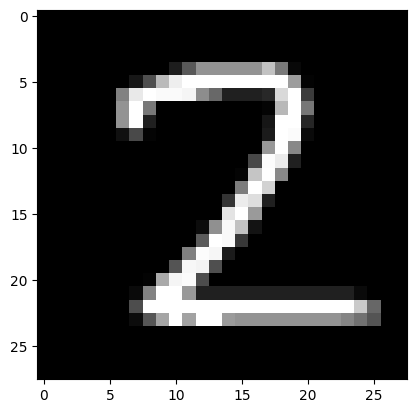

In [99]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)



In [100]:
# Fina accuracy on the dev set
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[9 4 1 9 3 0 2 2 3 9 1 7 4 1 3 7 5 9 6 0 3 6 3 3 6 9 2 7 1 3 3 4 2 9 7 7 3
 0 0 5 2 4 0 3 0 6 8 9 2 8 3 9 1 6 6 9 1 5 1 4 3 9 7 7 4 5 4 0 1 5 5 4 7 9
 1 3 4 7 7 7 2 4 3 3 2 3 7 0 1 1 5 0 0 1 3 3 0 0 7 4 4 2 2 7 7 8 5 9 5 6 4
 7 7 6 2 6 0 9 8 2 2 4 8 3 0 3 5 6 7 9 7 8 1 2 7 7 0 8 4 4 9 3 6 5 2 7 7 4
 7 0 3 1 7 1 8 1 1 4 2 0 0 7 2 2 1 4 3 1 2 1 9 6 3 0 5 5 7 7 9 0 5 5 0 7 8
 2 8 7 2 0 9 4 3 9 0 4 6 7 9 2 6 9 8 3 9 0 3 0 8 0 3 8 7 8 3 8 0 7 7 0 9 1
 5 9 4 4 3 7 0 7 8 8 3 5 2 7 6 3 8 4 8 5 5 9 9 9 9 1 6 9 3 8 3 0 8 2 4 1 4
 6 3 6 4 0 8 4 7 8 1 7 0 1 2 2 0 0 2 7 0 1 3 8 0 8 9 6 0 3 8 4 1 2 1 0 7 4
 7 2 5 2 6 6 7 9 1 0 8 7 1 8 6 2 5 6 9 7 2 5 7 6 0 7 4 7 7 2 2 4 9 2 3 8 3
 0 8 1 1 7 6 5 3 7 1 3 9 7 8 2 8 9 9 9 1 9 2 9 2 8 1 2 3 2 2 8 7 8 6 6 8 4
 6 3 6 9 0 5 2 7 3 3 6 0 7 0 0 2 1 0 2 5 2 1 5 7 1 1 5 3 9 1 3 1 6 3 8 0 8
 8 7 4 6 1 3 9 7 8 8 4 4 9 8 6 9 8 8 4 1 2 2 1 4 2 7 7 1 0 0 0 1 7 4 7 1 2
 2 6 9 0 2 0 0 9 8 1 2 9 5 7 4 1 7 8 2 1 9 3 5 0 8 1 8 9 8 7 3 1 1 6 4 3 5
 2 8 8 1 3 5 8 4 1 6 8 5 

np.float64(0.831)